#### **I. Import các thư viện**

In [26]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px

%matplotlib inline

#### **II. Import Data**

In [27]:

df = pd.read_csv('hanoi-aqi-weather-data.csv')  
df  

,UTC Time,Local Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2022-12-31T17:00:00,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.00,62.3,87,0.0,1024,73,14.8,0.0,0.66
1,2022-12-31T18:00:00,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.00,59.0,87,0.0,1023,75,14.6,0.0,1.00
2,2022-12-31T19:00:00,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.00,58.0,83,0.0,1023,79,14.3,0.0,1.00
3,2022-12-31T20:00:00,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.00,57.0,79,0.0,1023,82,14.1,0.0,1.00
4,2022-12-31T21:00:00,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.00,56.0,75,0.0,1022,86,13.8,0.0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2024-12-31T08:00:00,12/31/2024 15:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,173,605.0,15.0,27.0,100.0,73.00,26.0,37,0.0,1018,82,16.8,0.0,2.00
17540,2024-12-31T09:00:00,12/31/2024 16:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,165,806.0,8.0,15.1,94.0,67.00,26.0,1,0.0,1018,86,16.0,0.0,2.00
17541,2024-12-31T10:00:00,12/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,183,1310.0,10.3,10.8,108.0,80.33,28.0,0,0.0,1018,90,15.2,0.0,2.00
17542,2024-12-31T11:00:00,12/31/2024 18:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,168,1109.0,15.0,10.8,96.0,69.00,32.0,1,0.0,1019,94,14.4,0.0,1.60


In [28]:
df_1 = df.copy()

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UTC Time           17544 non-null  object 
 1   Local Time         17544 non-null  object 
 2   City               17544 non-null  object 
 3   Country Code       17544 non-null  object 
 4   Timezone           17544 non-null  object 
 5   AQI                17544 non-null  int64  
 6   CO                 17544 non-null  float64
 7   NO2                17544 non-null  float64
 8   O3                 17544 non-null  float64
 9   PM10               17544 non-null  float64
 10  PM25               17544 non-null  float64
 11  SO2                17544 non-null  float64
 12  Clouds             17544 non-null  int64  
 13  Precipitation      17544 non-null  float64
 14  Pressure           17544 non-null  int64  
 15  Relative Humidity  17544 non-null  int64  
 16  Temperature        175

In [30]:
df.shape

(17544, 19)

In [31]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,119.188440,586.002194,26.046255,53.999806,69.853836,49.333772,66.193382,70.481190,0.287819,1009.855734,77.972811,25.367522,1.334131,1.616586
std,54.214466,969.613080,28.068960,44.883112,84.185750,42.314439,49.174271,31.187022,1.031729,7.434626,15.235786,5.479729,1.952395,0.820656
min,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,983.000000,17.000000,7.700000,0.000000,0.000000
25%,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000,50.000000,0.000000,1004.000000,68.000000,21.600000,0.000000,1.000000
50%,108.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000,79.000000,0.000000,1009.000000,82.000000,26.200000,0.600000,1.600000
75%,154.000000,571.300000,29.000000,74.000000,80.000000,59.000000,97.000000,100.000000,0.000000,1015.000000,91.000000,29.200000,2.100000,2.000000
max,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000,100.000000,21.750000,1033.000000,100.000000,40.000000,12.100000,12.400000


#### **II. Phân tích và khám phá dữ liệu**
Trong phần này, phân tích khám phá dữ liệu (EDA) sẽ được sử dụng để xem xét bộ dữ liệu nhằm tìm kiếm các khuôn mẫu, phát hiện bất thường, kiểm định giả thuyết và xác minh các giả định. Quá trình này được thực hiện thông qua các thống kê mô tả và biểu đồ trực quan.

Trong suốt hơn 45 năm qua, Chỉ số Chất lượng Không khí (Air Quality Index – AQI), được phát triển bởi Cơ quan Bảo vệ Môi trường Hoa Kỳ (USEPA), đã cung cấp những thông tin quan trọng cho công chúng về tình trạng ô nhiễm không khí.
Chỉ số AQI được tính toán dựa trên nồng độ đo được của các chất ô nhiễm bao gồm: Carbon Monoxide (CO), Nitrogen Dioxide (NO2), Ozone (O3), hạt bụi mịn PM2.5 và PM10, cùng với Sulfur Dioxide (SO2).

Trong đó, PM25 (biểu thị vật có đường kính nhỏ hơn hoặc bằng 2.5 micromet) là yếu tố chính gây nguy hại đến sức khỏe con người, và thường được sử dụng như chỉ tiêu quan trọng trong các tiêu chuẩn đánh giá chất lượng không khí.

Theo Báo cáo Chất lượng Không khí Toàn cầu năm 2019 của [IQAir](https://www.iqair.com/vi/newsroom/resources-what-is-aqi), nồng độ PM₂.₅ được chia thành các nhóm mức độ khác nhau để xác định tình trạng chất lượng không khí, cụ thể như sau:
![](./images/anh.png)


In [32]:
df.describe()

,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,119.188440,586.002194,26.046255,53.999806,69.853836,49.333772,66.193382,70.481190,0.287819,1009.855734,77.972811,25.367522,1.334131,1.616586
std,54.214466,969.613080,28.068960,44.883112,84.185750,42.314439,49.174271,31.187022,1.031729,7.434626,15.235786,5.479729,1.952395,0.820656
min,4.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,983.000000,17.000000,7.700000,0.000000,0.000000
25%,76.000000,135.400000,11.300000,22.300000,31.800000,24.000000,26.000000,50.000000,0.000000,1004.000000,68.000000,21.600000,0.000000,1.000000
50%,108.000000,212.400000,18.000000,41.700000,50.000000,38.000000,61.300000,79.000000,0.000000,1009.000000,82.000000,26.200000,0.600000,1.600000
75%,154.000000,571.300000,29.000000,74.000000,80.000000,59.000000,97.000000,100.000000,0.000000,1015.000000,91.000000,29.200000,2.100000,2.000000
max,500.000000,15956.200000,378.000000,700.000000,1103.000000,446.000000,400.000000,100.000000,21.750000,1033.000000,100.000000,40.000000,12.100000,12.400000


In [33]:
df.head(10)

,UTC Time,Local Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2022-12-31T17:00:00,1/1/2023 0:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
1,2022-12-31T18:00:00,1/1/2023 1:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2,2022-12-31T19:00:00,1/1/2023 2:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
3,2022-12-31T20:00:00,1/1/2023 3:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
4,2022-12-31T21:00:00,1/1/2023 4:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00
5,2022-12-31T22:00:00,1/1/2023 5:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,172,204.8,8.3,46.0,90.0,72.0,56.7,46,0.0,1022,91,13.0,0.0,1.00
6,2022-12-31T23:00:00,1/1/2023 6:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,210.7,10.7,42.0,80.0,64.0,57.3,48,0.0,1023,93,12.0,0.0,1.00
7,2023-01-01T00:00:00,1/1/2023 7:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,160,216.5,13.0,38.0,78.8,63.0,58.0,12,0.0,1024,96,11.2,1.9,1.60
8,2023-01-01T01:00:00,1/1/2023 8:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,165,209.5,11.0,45.7,83.8,67.0,57.7,6,0.0,1024,79,13.5,2.3,0.66
9,2023-01-01T02:00:00,1/1/2023 9:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,176,202.5,9.0,53.3,93.8,75.0,57.3,5,0.0,1024,65,15.9,3.2,1.33


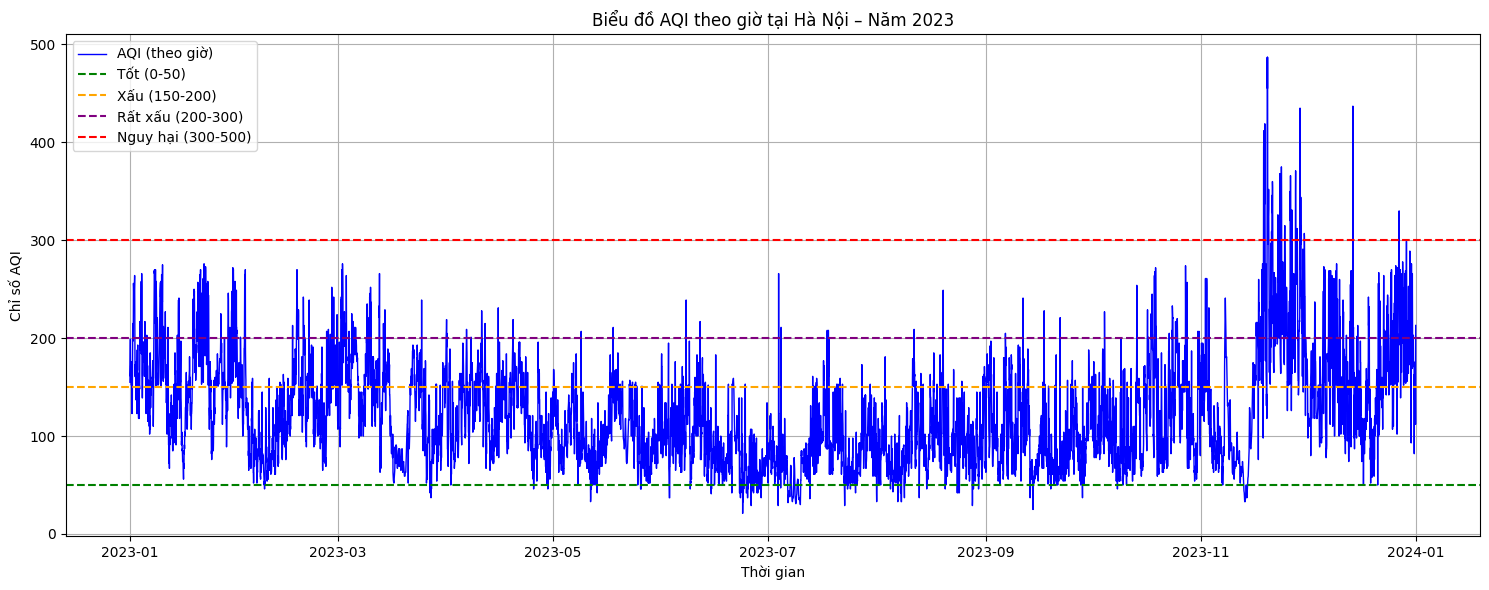

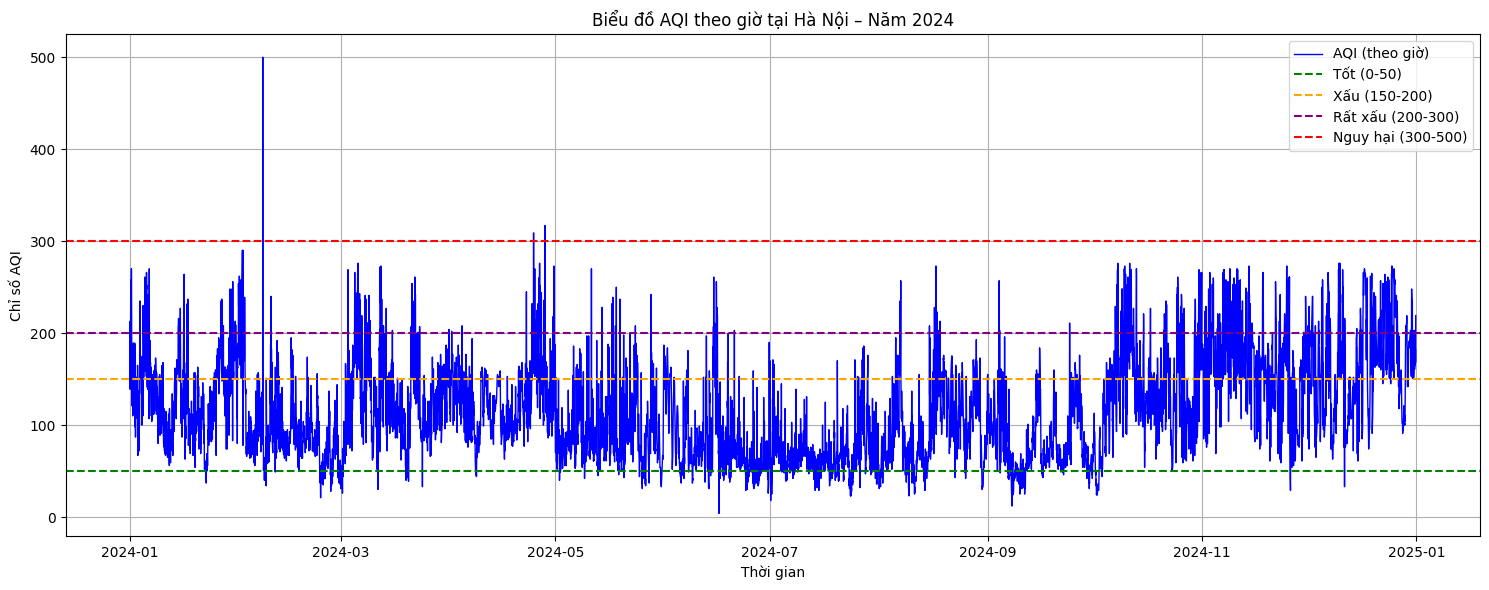

Năm 2023: AQI cao nhất = 487 vào lúc 2023-11-19 20:00:00
Năm 2024: AQI cao nhất = 500 vào lúc 2024-02-07 19:00:00


In [34]:
df['Local Time'] = pd.to_datetime(df['Local Time'])

df_2023 = df[df['Local Time'].dt.year == 2023]
df_2024 = df[df['Local Time'].dt.year == 2024]

# Biểu đồ năm 2023
plt.figure(figsize=(15,6))
plt.plot(df_2023['Local Time'], df_2023['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2023')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Biểu đồ năm 2024
plt.figure(figsize=(15,6))
plt.plot(df_2024['Local Time'], df_2024['AQI'], color='blue', linewidth=1, label='AQI (theo giờ)')
plt.title('Biểu đồ AQI theo giờ tại Hà Nội – Năm 2024')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số AQI')
plt.axhline(y=50, color='green', linestyle='--', label='Tốt (0-50)')
plt.axhline(y=150, color='orange', linestyle='--', label='Xấu (150-200)')
plt.axhline(y=200, color='purple', linestyle='--', label='Rất xấu (200-300)')
plt.axhline(y=300, color='red', linestyle='--', label='Nguy hại (300-500)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


max_2023 = df_2023.loc[df_2023['AQI'].idxmax()]
max_2024 = df_2024.loc[df_2024['AQI'].idxmax()]
print(f"Năm 2023: AQI cao nhất = {max_2023['AQI']} vào lúc {max_2023['Local Time']}")
print(f"Năm 2024: AQI cao nhất = {max_2024['AQI']} vào lúc {max_2024['Local Time']}")


Từ biểu đồ, có thể thấy chỉ số AQI của Hà Nội dao động chủ yếu trong khoảng 50-200 (Trung bình đến Xấu). Chỉ số này hiếm khi duy trì ở mức Tốt (0-50). Chỉ số cũng có tần suất cao vượt ngưỡng Không tốt. Đặc biệt, chỉ số này ở mức Nguy hại (>300) vào các thời điểm khác nhau từ tháng 11 đến giữa tháng 2, đạt mức cao nhất trong năm vào lúc 19h 7/2/2024 và đạt AQI = 487 vào lúc 20h ngày 19/11/2023.

Nhìn chung, Hà Nội đã phải đối mặt với tình trạng ô nhiễm không khí nghiêm trọng trong năm qua, điều này có thể ảnh hưởng nghiêm trọng đến sức khỏe của người dân thành phố.

In [35]:

df['month'] = df['Local Time'].dt.month
df['year'] = df['Local Time'].dt.year

monthly_stats = (df.groupby(['year', 'month']).agg(
    mean_AQI = ('AQI', 'mean'),
    max_AQI = ('AQI', 'max'),
    std_AQI = ('AQI', 'std'),
    count_hazardous=('AQI', lambda x: (x>300).sum())
    
).reset_index()
                )
monthly_stats = monthly_stats.sort_values('mean_AQI', ascending=False)
months_over_300 = monthly_stats[monthly_stats['count_hazardous'] > 0]
print(months_over_300[['year', 'month', 'mean_AQI', 'count_hazardous']])


    year  month    mean_AQI  count_hazardous
10  2023     11  166.684722               52
11  2023     12  165.413978                2
15  2024      4  128.120666                2
13  2024      2   96.771552                1


In [36]:
df_1['Local Time'] = pd.to_datetime(df_1['Local Time'])


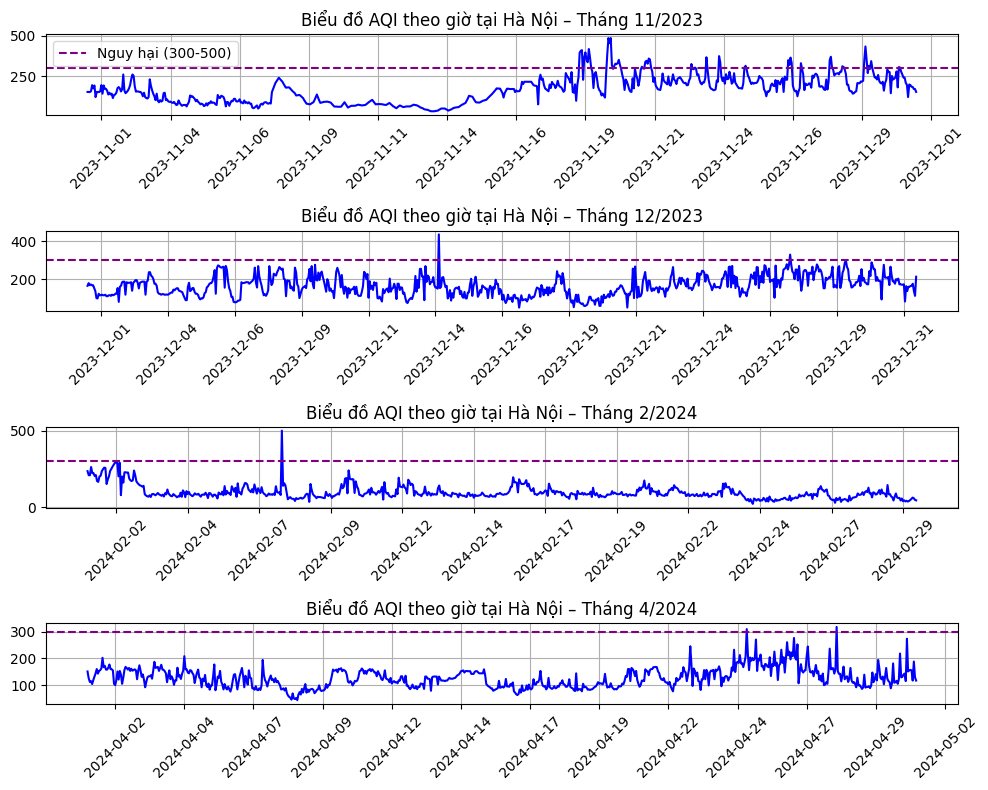

In [37]:
fig, axs = plt.subplots(4, 1, figsize=(10, 8))

# Set index cho df_1
df_1 = df_1.set_index('Local Time')

# Vẽ biểu đồ cho từng tháng
axs[0].plot(df_1.loc['2023-11-01':'2023-11-30']["AQI"], color='b')
axs[0].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 11/2023')
axs[0].grid(True)
axs[0].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')
axs[0].legend()


axs[1].plot(df_1.loc['2023-12-01':'2023-12-31']["AQI"], color='b')
axs[1].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 12/2023')
axs[1].grid(True)
axs[1].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[2].plot(df_1.loc['2024-02-01':'2024-02-29']["AQI"], color='b')
axs[2].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 2/2024')
axs[2].grid(True)
axs[2].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


axs[3].plot(df_1.loc['2024-04-01':'2024-04-30']["AQI"], color='b')
axs[3].set_title('Biểu đồ AQI theo giờ tại Hà Nội – Tháng 4/2024')
axs[3].grid(True)
axs[3].axhline(y=300, color='purple', linestyle='--', label='Nguy hại (300-500)')


for ax in axs:
    ax.xaxis.set_major_locator(plt.MaxNLocator(15))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


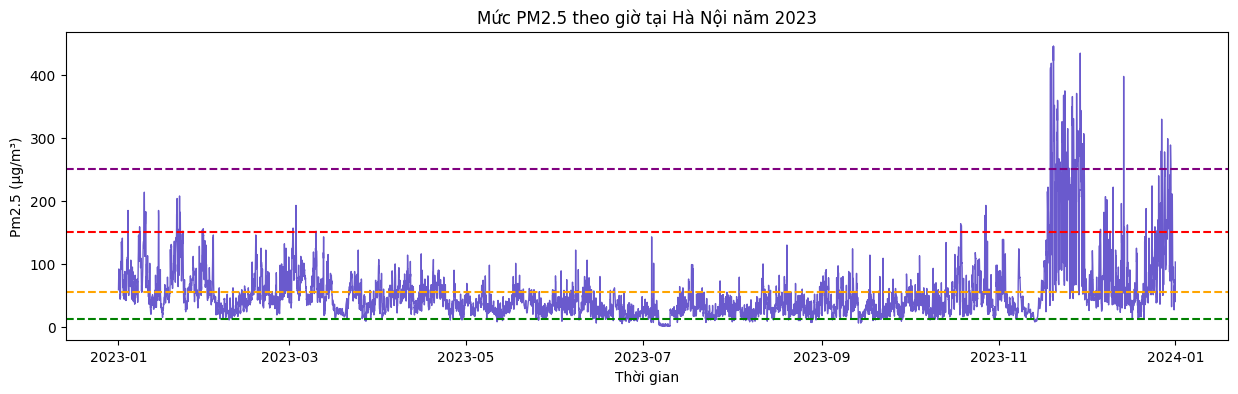

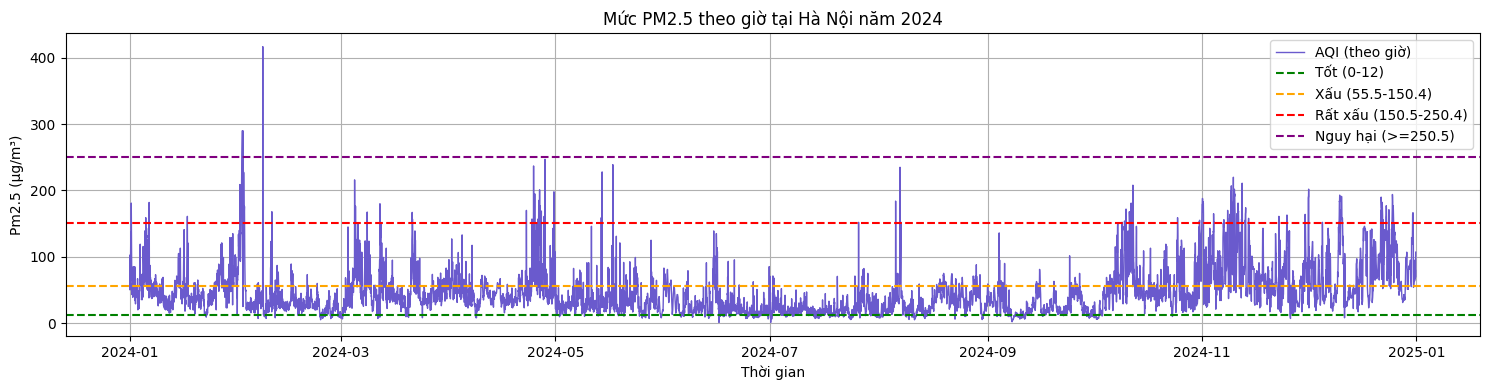

In [38]:
# Năm 2023

plt.figure(figsize=(15, 4))
plt.plot(df_2023['Local Time'], df_2023['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2023')
plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')

# Năm 2024
plt.figure(figsize=(15, 4))
plt.plot(df_2024['Local Time'], df_2024['PM25'], color='slateblue', linewidth=1, label='AQI (theo giờ)')
plt.xlabel('Thời gian')
plt.ylabel('Pm2.5 (μg/m³)')
plt.title('Mức PM2.5 theo giờ tại Hà Nội năm 2024')

plt.axhline(y=12, color='green', linestyle='--', label='Tốt (0-12)')
plt.axhline(y=55.5, color='orange', linestyle='--', label='Xấu (55.5-150.4)')
plt.axhline(y=150.5, color='red', linestyle='--', label='Rất xấu (150.5-250.4)')
plt.axhline(y=250.5, color='purple', linestyle='--', label='Nguy hại (>=250.5)')


plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17544 entries, 2023-01-01 00:00:00 to 2024-12-31 19:00:00
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UTC Time           17544 non-null  object 
 1   City               17544 non-null  object 
 2   Country Code       17544 non-null  object 
 3   Timezone           17544 non-null  object 
 4   AQI                17544 non-null  int64  
 5   CO                 17544 non-null  float64
 6   NO2                17544 non-null  float64
 7   O3                 17544 non-null  float64
 8   PM10               17544 non-null  float64
 9   PM25               17544 non-null  float64
 10  SO2                17544 non-null  float64
 11  Clouds             17544 non-null  int64  
 12  Precipitation      17544 non-null  float64
 13  Pressure           17544 non-null  int64  
 14  Relative Humidity  17544 non-null  int64  
 15  Temperature        17544 non-null  

In [41]:
# Bước 1: chuyển cột Local Time sang dạng datetime
df['Local Time'] = pd.to_datetime(df['Local Time'], errors='coerce')

# Bước 2: đặt nó làm index
df = df.set_index('Local Time')
hourly_pm25 = df['PM25'].groupby(df.index.hour).mean()
highest_hours = hourly_pm25.nlargest(5) 
print(highest_hours)

Local Time
8     56.333871
20    55.918123
9     55.453078
21    54.531959
6     54.371696
Name: PM25, dtype: float64


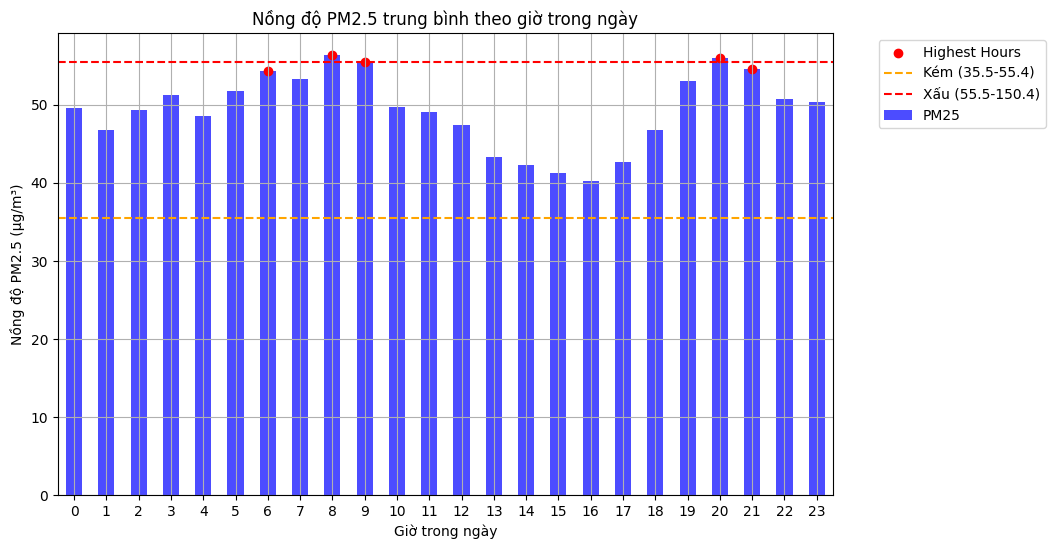

In [42]:
plt.figure(figsize=(10, 6))
hourly_pm25.plot(kind='bar', color='blue', alpha=0.7)  
plt.scatter(highest_hours.index, highest_hours.values, color='red', label='Highest Hours') 
plt.title('Nồng độ PM2.5 trung bình theo giờ trong ngày')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Nồng độ PM2.5 (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.xticks(rotation='horizontal')

plt.show()


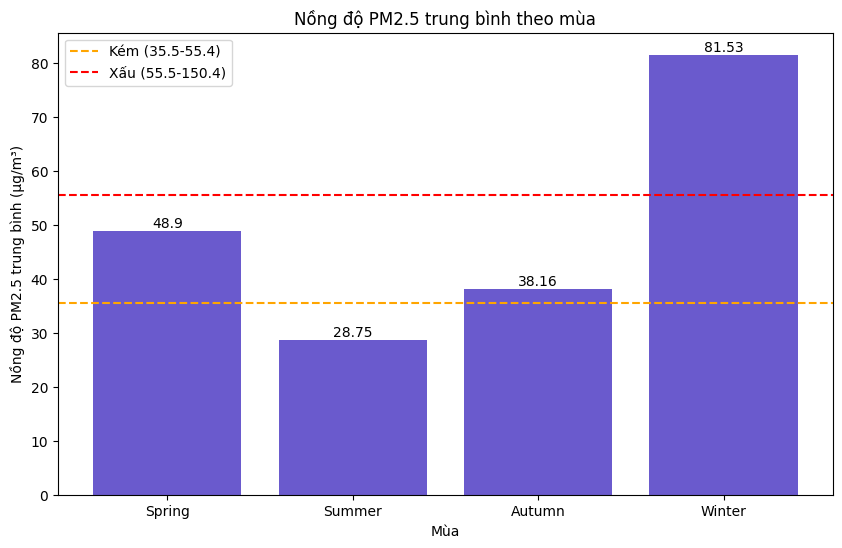

In [43]:
seasons = {
    'Spring': [2, 3, 4],
    'Summer': [5, 6, 7],
    'Autumn': [8, 9, 10],
    'Winter': [11, 12, 1]
}


seasonal_pm25 = {}
for season, months in seasons.items():
    seasonal_pm25[season] = df.loc[df.index.month.isin(months), 'PM25'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_pm25.keys(), seasonal_pm25.values(), color='slateblue')
plt.title('Nồng độ PM2.5 trung bình theo mùa')
plt.xlabel('Mùa')
plt.ylabel('Nồng độ PM2.5 trung bình (μg/m³)')
plt.axhline(y=35.5, color='orange', linestyle='--', label='Kém (35.5-55.4)')
plt.axhline(y=55.5, color='red', linestyle='--', label='Xấu (55.5-150.4)')
plt.legend()


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

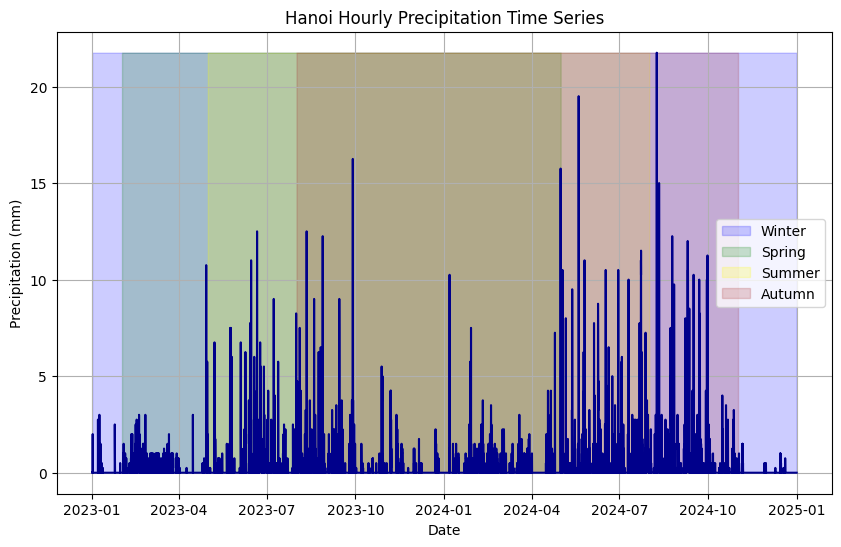

Annual Precipitation: 5049.5 mm


In [44]:
# Plot precipitation variable
plt.figure(figsize=(10, 6))

# Define seasons (assuming meteorological seasons: winter, spring, summer, autumn)
winter_months = [11, 12, 1]
spring_months = [2, 3, 4]
summer_months = [5, 6, 7]
autumn_months = [8, 9, 10]

# Plot entire precipitation time series
plt.plot(df.index, df['Precipitation'], color='darkblue')

# Shade winter season
plt.fill_between(df.index[df.index.month.isin(winter_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='blue', alpha=0.2, label='Winter')

# Shade spring season
plt.fill_between(df.index[df.index.month.isin(spring_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='green', alpha=0.2, label='Spring')

# Shade summer season
plt.fill_between(df.index[df.index.month.isin(summer_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='yellow', alpha=0.2, label='Summer')

# Shade autumn season
plt.fill_between(df.index[df.index.month.isin(autumn_months)], df['Precipitation'].min(), df['Precipitation'].max(), color='brown', alpha=0.2, label='Autumn')

# Set title and labels
plt.title('Hanoi Hourly Precipitation Time Series')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')

# Add legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

# Group data by year and calculate total precipitation for each year
annual_total_precipitation = df['Precipitation'].sum()

print("Annual Precipitation:", annual_total_precipitation, "mm")

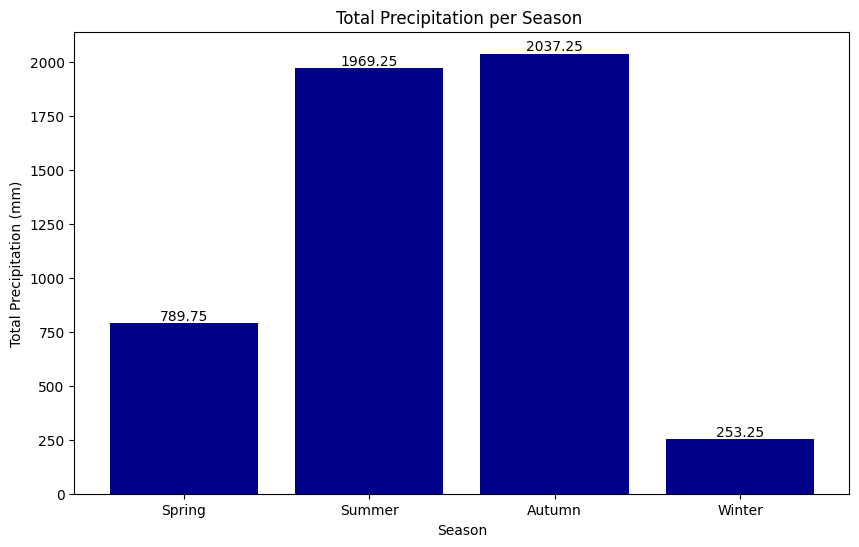

In [45]:

# Define seasons
seasons = {
    'Spring': [2, 3, 4],
    'Summer': [5, 6, 7],
    'Autumn': [8, 9, 10],
    'Winter': [11, 12, 1]
}

# Group data by season and calculate total precipitation for each season
seasonal_precipitation = {}
for season, months in seasons.items():
    seasonal_precipitation[season] = df.loc[df.index.month.isin(months), 'Precipitation'].sum()

# Plot the total precipitation for each season
plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_precipitation.keys(), seasonal_precipitation.values(), color='darkblue')
plt.title('Total Precipitation per Season ')
plt.xlabel('Season')
plt.ylabel('Total Precipitation (mm)')

# Annotate the bars with the total precipitation values for each season
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')

plt.show()

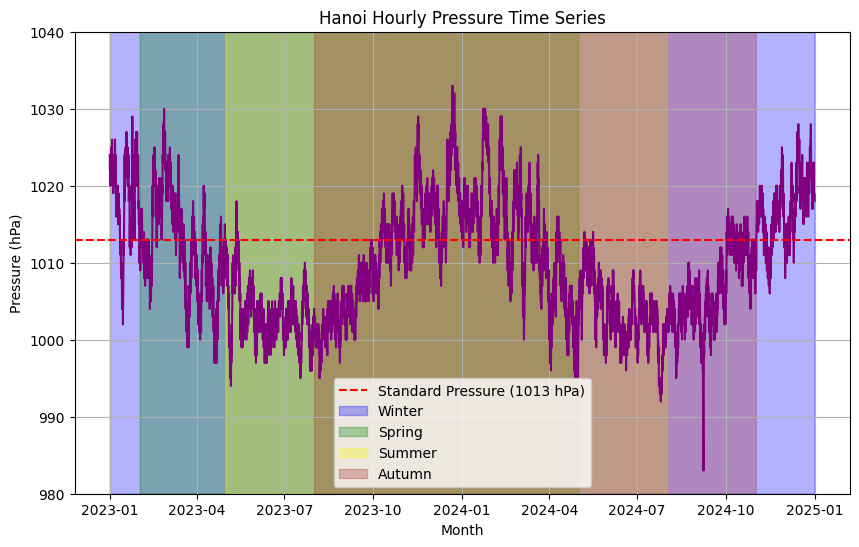

In [46]:
# Define seasons (assuming meteorological seasons: winter, spring, summer, autumn)
winter_months = [11, 12, 1]
spring_months = [2, 3, 4]
summer_months = [5, 6, 7]
autumn_months = [8, 9, 10]

# Plot pressure variable as a line plot
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(df.index, df['Pressure'], color='purple')  # Line plot

# Add a horizontal line at 1013 hPa with a label
plt.axhline(y=1013, color='red', linestyle='--', label='Standard Pressure (1013 hPa)')

# Shade winter season
plt.fill_between(df.index[df.index.month.isin(winter_months)], 980, 1040, color='blue', alpha=0.3, label='Winter')

# Shade spring season
plt.fill_between(df.index[df.index.month.isin(spring_months)], 980, 1040, color='green', alpha=0.3, label='Spring')

# Shade summer season
plt.fill_between(df.index[df.index.month.isin(summer_months)], 980, 1040, color='yellow', alpha=0.3, label='Summer')

# Shade autumn season
plt.fill_between(df.index[df.index.month.isin(autumn_months)], 980, 1040, color='brown', alpha=0.3, label='Autumn')

plt.title('Hanoi Hourly Pressure Time Series')  # Set the title
plt.xlabel('Month')  # Set the x-axis label
plt.ylabel('Pressure (hPa)')  # Set the y-axis label
plt.ylim(980, 1040)  # Set the y-axis limits
plt.grid(True)  # Add gridlines
plt.legend()  # Show legend
plt.show()  # Display the plot

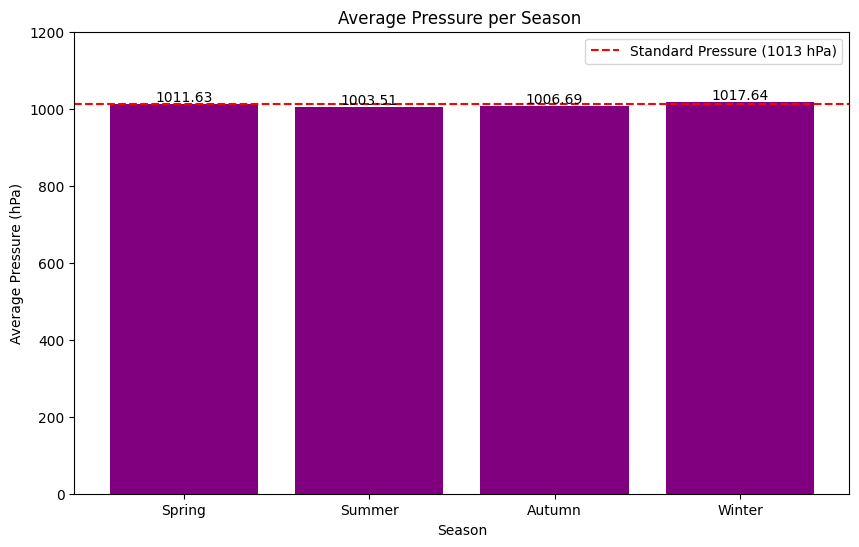

In [47]:
# Define seasons
seasons = {
    'Spring': [2, 3, 4],
    'Summer': [5, 6, 7],
    'Autumn': [8, 9, 10],
    'Winter': [11, 12, 1]
}

# Group data by season and calculate average humidity for each season
seasonal_humid = {}
for season, months in seasons.items():
    seasonal_humid[season] = df.loc[df.index.month.isin(months), 'Pressure'].mean()

# Plot the average humidity for each season
plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_humid.keys(), seasonal_humid.values(), color='purple')
plt.axhline(y=1013, color='red', linestyle='--', label='Standard Pressure (1013 hPa)')
plt.title('Average Pressure per Season ')
plt.xlabel('Season')
plt.ylabel('Average Pressure (hPa)')
plt.ylim(0, 1200)  # Set the y-axis limits

# Annotate the bars with the average humidity values for each season
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2),
             ha='center', va='bottom')
plt.legend()  # Show legend
plt.show()

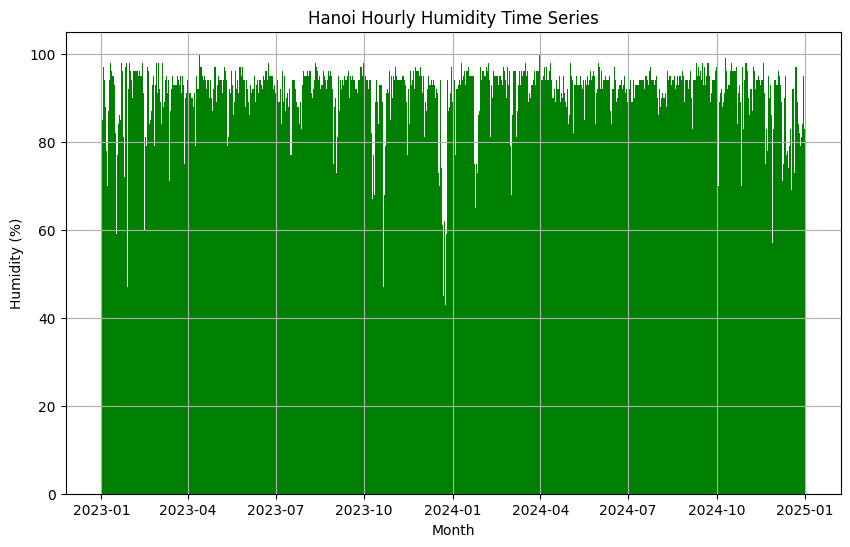

Average Annual Relative Humidity: 77.97 %


In [48]:

# Plot humidity variable
plt.figure(figsize=(10, 6))  # Set the figure size
plt.bar(df.index, df['Relative Humidity'], color='green', linestyle='-')  # Line plot
plt.title('Hanoi Hourly Humidity Time Series')  # Set the title
plt.xlabel('Month')  # Set the x-axis label
plt.ylabel('Humidity (%)')  # Set the y-axis label
plt.grid(True)  # Add gridlines
plt.show()  # Display the plot

# Calculate the average of the annual mean relative humidity values
average_annual_rh = df["Relative Humidity"].mean()

print("Average Annual Relative Humidity:", round(average_annual_rh, 2), '%')

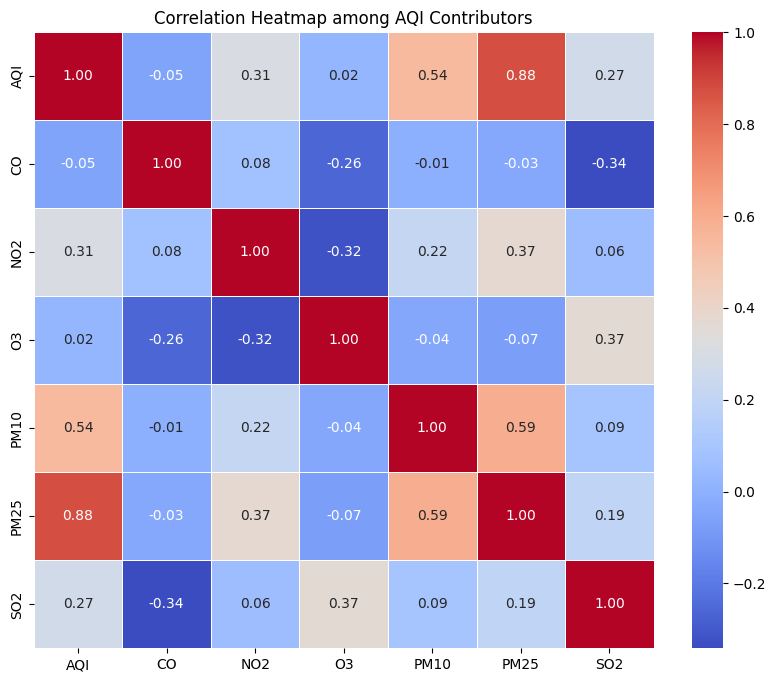

In [49]:
# Select the relevant columns
corr_columns = ['AQI', 'CO', 'NO2', 'O3', 'PM10', 'PM25', 'SO2']

# Calculate the correlation matrix
correlation_matrix = df[corr_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap among AQI Contributors')
plt.show()